# Case Study 1 — Feedback → Roadmap
### VoltRide (fiktiv) · alles in einer Datei · Kosten ≈ 0 €

**So benutzt du dieses Notebook:** `Laufzeit → Alle ausführen`. Danach von oben nach unten
durchgehen. Es gibt keine Code-Schnipsel mehr, die du irgendwo einfügen musst.

| | |
|---|---|
| **Zelle 1** | Setup und Verbindung |
| **Zelle 2** | Motor — alle Funktionen. Einmal ausführen, nie wieder anfassen. |
| **Zelle 3** | Daten laden |
| **Zelle 4** | **Preflight** — prüft, welche Modell-Features funktionieren, *bevor* 60 Aufrufe verbrannt werden |
| **Zelle 5** | Lauf v1 und v2, Ergebnistabelle |
| **Zelle 6** | Fehlertabelle für deine Analyse |
| **Zelle 7** | 🔧 deine weiteren Läufe |
| **Zelle 8** | Roadmap, Diagramm, Kosten |

**Was anders ist als vorher:**

- Fehlgeschlagene Aufrufe werden **nicht** als Vorhersage getarnt. Sie bekommen `ok=False`, und
  die Genauigkeit wird nur über erfolgreiche Zeilen gerechnet. Die Spalte `Erfolgsquote` zeigt
  dir sofort, ob den Zahlen zu trauen ist.
- Nur Erfolge landen im Cache. Ein fehlgeschlagener Aufruf wird beim nächsten Mal wiederholt.
- Der Preflight probiert automatisch durch, welche Kombination aus `reasoning_effort` und
  `response_format` dein Modell unterstützt. Kein Raten mehr.
- Bis zu drei Versuche pro Eintrag, mit Wartezeit bei Rate-Limits.

---
## Zelle 1 · Setup

Groq-Key: [console.groq.com/keys](https://console.groq.com/keys) → in Colab links auf 🔑 Secrets →
Name `GROQ_API_KEY` → **Notebookzugriff aktivieren**.

In [ ]:
!pip install -q openai pandas matplotlib

In [ ]:
import os
from openai import OpenAI

try:
    from google.colab import userdata
    KEY = userdata.get("GROQ_API_KEY")
except Exception:
    KEY = os.environ.get("GROQ_API_KEY")

assert KEY, "Kein Key gefunden. Secret GROQ_API_KEY anlegen und Notebookzugriff aktivieren."
client = OpenAI(api_key=KEY, base_url="https://api.groq.com/openai/v1")
print("Verbunden.")

Verbunden.


---
## Zelle 2 · Motor

Einmal ausführen. Hier musst du nichts ändern — auch nicht für v3, v4, v5.

In [ ]:
# ============================================================
# VoltRide Case Study 1 - Engine
# ============================================================
import os, re, json, time, hashlib, pathlib
import pandas as pd, numpy as np

MODELL      = "openai/gpt-oss-20b"
MAX_TOKENS  = 1200
PAUSE       = 2.1
VERSUCHE    = 3

CLUSTER   = ["unlock_issue","app_crash","bike_defect","safety","pricing",
             "coverage","billing","praise","noise"]
SENTIMENT = ["pos","neg","neutral"]

SCHEMA = {
    "type": "object",
    "properties": {
        "cluster":         {"type": "string",  "enum": CLUSTER},
        "sentiment":       {"type": "string",  "enum": SENTIMENT},
        "feature_request": {"type": "integer", "enum": [0, 1]},
        "severity":        {"type": "integer", "enum": [1, 2, 3, 4]},
    },
    "required": ["cluster","sentiment","feature_request","severity"],
    "additionalProperties": False,
}

def _rf(modus):
    if modus == "schema_strict":
        return {"type":"json_schema","json_schema":{"name":"k","strict":True,"schema":SCHEMA}}
    if modus == "schema_lose":
        return {"type":"json_schema","json_schema":{"name":"k","strict":False,"schema":SCHEMA}}
    if modus == "json_objekt":
        return {"type":"json_object"}
    return None

PROMPT_BASIS = """Du klassifizierst Nutzerfeedback fuer einen E-Bike-Sharing-Dienst.

Ordne den Text genau einer Kategorie zu: {cluster}

Text: {text}"""

PROMPT_MIT_FORMAT = """Du klassifizierst Nutzerfeedback fuer einen E-Bike-Sharing-Dienst.

Antworte ausschliesslich mit einem JSON-Objekt in genau dieser Form:
{{"cluster": "app_crash", "sentiment": "neg", "feature_request": 0, "severity": 3}}

Erlaubte Werte:
- cluster: {cluster}
- sentiment: pos, neg, neutral
- feature_request: 0 oder 1
- severity: 1, 2, 3, 4

Text: {text}"""

CACHE = pathlib.Path("cache")

def _json_aus_text(s):
    s = (s or "").strip()
    if s.startswith("```"):
        s = re.sub(r"^```[a-zA-Z]*\s*", "", s)
        s = re.sub(r"```\s*$", "", s).strip()
    try:
        return json.loads(s)
    except Exception:
        pass
    a, b = s.find("{"), s.rfind("}")
    if a != -1 and b > a:
        return json.loads(s[a:b+1])
    raise ValueError(f"kein JSON in Antwort: {s[:80]!r}")

def _normalisiere(e):
    def zahl(x, standard):
        try:
            return int(str(x).strip())
        except Exception:
            return standard
    return {
        "cluster":         str(e.get("cluster","")).strip().lower(),
        "sentiment":       str(e.get("sentiment","")).strip().lower(),
        "feature_request": zahl(e.get("feature_request"), -1),
        "severity":        zahl(e.get("severity"), -1),
    }

def _gueltig(e):
    return (e["cluster"] in CLUSTER and e["sentiment"] in SENTIMENT
            and e["feature_request"] in (0,1) and e["severity"] in (1,2,3,4))

# --- wird von preflight() gesetzt
MODUS_FREI   = "json_objekt"
MODUS_SCHEMA = "schema_strict"
REASONING    = True
# client wird in Zelle 1 gesetzt

def _erzeuge(inhalt, modus, reasoning):
    kw = dict(model=MODELL, temperature=0.0, max_tokens=MAX_TOKENS,
              messages=[{"role":"user","content":inhalt}])
    rf = _rf(modus)
    if rf is not None:
        kw["response_format"] = rf
    if reasoning:
        kw["reasoning_effort"] = "low"
    r = client.chat.completions.create(**kw)
    inhalt_antwort = r.choices[0].message.content
    u = getattr(r, "usage", None)
    return inhalt_antwort, (getattr(u,"prompt_tokens",0), getattr(u,"completion_tokens",0))

def _prompt_fuer(modus):
    return PROMPT_BASIS if str(modus).startswith("schema") else PROMPT_MIT_FORMAT

def probe(modus, reasoning, text="Die Bremse hat auf der Fahrt komplett versagt."):
    inhalt = _prompt_fuer(modus).format(text=text, cluster=", ".join(CLUSTER))
    roh, _ = _erzeuge(inhalt, modus, reasoning)
    e = _normalisiere(_json_aus_text(roh))
    if not _gueltig(e):
        raise ValueError(f"ungueltige Werte: {e}")
    return e

def preflight(verbose=True):
    """Findet eine funktionierende Kombination, bevor 60 Aufrufe verbrannt werden."""
    global MODUS_FREI, MODUS_SCHEMA, REASONING
    def sag(*a):
        if verbose: print(*a)

    REASONING = None
    for r in (True, False):
        try:
            probe("json_objekt", r)
            REASONING = r
            sag(f"[1/3] Verbindung ok. reasoning_effort={'low' if r else 'nicht gesetzt'}")
            break
        except Exception as ex:
            sag(f"      reasoning={r}: {str(ex)[:90]}")
    if REASONING is None:
        sag("FEHLGESCHLAGEN: keine Verbindung / keine gueltige Antwort.")
        return False

    MODUS_FREI = None
    for m in ("json_objekt", "frei"):
        try:
            probe(m, REASONING); MODUS_FREI = m
            sag(f"[2/3] Baseline-Modus: {m}")
            break
        except Exception as ex:
            sag(f"      {m}: {str(ex)[:90]}")
    if MODUS_FREI is None:
        sag("FEHLGESCHLAGEN: kein Baseline-Modus moeglich.")
        return False

    MODUS_SCHEMA = None
    for m in ("schema_strict", "schema_lose"):
        try:
            e = probe(m, REASONING); MODUS_SCHEMA = m
            sag(f"[3/3] Schema-Modus: {m}   Testausgabe: {e}")
            break
        except Exception as ex:
            sag(f"      {m}: {str(ex)[:90]}")
    if MODUS_SCHEMA is None:
        sag("[3/3] Kein Schema-Modus verfuegbar - Validierung uebernimmt der Code.")
    sag("\nPreflight abgeschlossen.")
    return True

def klassifiziere(text, prompt, modus):
    CACHE.mkdir(exist_ok=True)
    key = hashlib.md5("|".join([prompt, text, MODELL, str(modus), str(REASONING)]).encode()).hexdigest()
    f = CACHE / f"{key}.json"
    if f.exists():
        return json.loads(f.read_text())

    inhalt = prompt.format(text=text, cluster=", ".join(CLUSTER))
    letzter = ""
    for _ in range(VERSUCHE):
        try:
            roh, (t_ein, t_aus) = _erzeuge(inhalt, modus, REASONING)
            e = _normalisiere(_json_aus_text(roh))
            if _gueltig(e):
                e.update(ok=True, tokens_ein=t_ein, tokens_aus=t_aus)
                f.write_text(json.dumps(e))      # nur Erfolge cachen
                time.sleep(PAUSE)
                return e
            letzter = f"ungueltige Werte: {e}"
        except Exception as ex:
            letzter = str(ex)[:160]
            if "429" in letzter or "rate limit" in letzter.lower():
                time.sleep(20)
        time.sleep(PAUSE)

    return {"cluster":None,"sentiment":None,"feature_request":None,"severity":None,
            "ok":False,"fehler":letzter,"tokens_ein":0,"tokens_aus":0}

def lauf(eingabe, prompt, name, modus):
    zeilen, fehler = [], []
    for n, (_, r) in enumerate(eingabe.iterrows(), 1):
        e = klassifiziere(r.text, prompt, modus)
        if not e["ok"]:
            fehler.append((r.id, e.get("fehler","")))
        zeilen.append({"id": r.id,
                       "cluster": e["cluster"], "sentiment": e["sentiment"],
                       "feature_request": e["feature_request"], "severity": e["severity"],
                       "ok": e["ok"], "tokens_ein": e["tokens_ein"], "tokens_aus": e["tokens_aus"]})
        if n % 15 == 0:
            print(f"   {n}/{len(eingabe)}")
    df = pd.DataFrame(zeilen)
    n_ok = int(df.ok.sum())
    print(f"   Lauf '{name}': {n_ok}/{len(df)} erfolgreich")
    if fehler:
        print(f"   {len(fehler)} fehlgeschlagen, erster Grund: {fehler[0][1][:110]}")
    return df

def bewerte(wahrheit, v, name):
    m = wahrheit.merge(v, on="id")
    g = m[m.ok]
    r = {"Lauf": name, "Erfolgsquote": len(g)/len(m) if len(m) else 0.0}
    if len(g) == 0:
        for k in ["Cluster","Sentiment","Feature-Request","Severity","Sicherheit-Recall","Noise-Recall"]:
            r[k] = float("nan")
        r["Ø Token aus"] = 0
        return r
    r["Cluster"]         = (g.cluster == g.cluster_wahr).mean()
    r["Sentiment"]       = (g.sentiment == g.sentiment_wahr).mean()
    r["Feature-Request"] = (g.feature_request == g.feature_request_wahr).mean()
    r["Severity"]        = (g.severity == g.severity_wahr).mean()
    s = g[g.cluster_wahr == "safety"]
    r["Sicherheit-Recall"] = (s.cluster == "safety").mean() if len(s) else float("nan")
    n = g[g.cluster_wahr == "noise"]
    r["Noise-Recall"]      = (n.cluster == "noise").mean() if len(n) else float("nan")
    r["Ø Token aus"]       = int(v.tokens_aus.mean())
    return r

def tafel(protokoll):
    t = pd.DataFrame(protokoll).set_index("Lauf")
    prozent = [c for c in t.columns if c != "Ø Token aus"]
    return t.style.format({c: "{:.0%}" for c in prozent})

def verteilung(wahrheit, laeufe):
    d = {"wahr": wahrheit.cluster_wahr.value_counts()}
    for name, v in laeufe.items():
        d[name] = v[v.ok].cluster.value_counts()
    return pd.DataFrame(d).fillna(0).astype(int)

def fehlertabelle(wahrheit, eingabe, v, datei):
    m = wahrheit.merge(v, on="id").merge(eingabe, on="id")
    f = m[(m.ok) & (m.cluster != m.cluster_wahr)][
        ["id","text","cluster_wahr","cluster","sentiment_wahr","sentiment",
         "feature_request_wahr","feature_request","severity_wahr","severity"]].copy()
    f["code"] = ""
    f["notiz"] = ""
    f["label_strittig"] = 0
    f.to_csv(datei, index=False, encoding="utf-8-sig")
    return f

def severity_fehler(wahrheit, eingabe, v):
    m = wahrheit.merge(v, on="id").merge(eingabe, on="id")
    return m[(m.ok) & (m.cluster == m.cluster_wahr) & (m.severity != m.severity_wahr)][
        ["id","text","cluster_wahr","severity_wahr","severity"]]

---
## Zelle 3 · Daten

`feedback_voltride.csv` neben das Notebook legen (Colab: links 📁, per Drag & Drop).

Die `*_wahr`-Spalten sind dein Prüfmaßstab und werden vom Modell nie gesehen.

In [ ]:
DF = pd.read_csv("feedback_voltride.csv")

WAHRHEIT = DF[["id","cluster_wahr","sentiment_wahr","feature_request_wahr","severity_wahr"]].copy()
EINGABE  = DF[["id","text"]].copy()

print(f"{len(EINGABE)} Einträge geladen")
print(WAHRHEIT.cluster_wahr.value_counts().to_string())

60 Einträge geladen
cluster_wahr
app_crash       11
coverage        10
unlock_issue     9
billing          6
bike_defect      6
praise           6
pricing          5
noise            4
safety           3


---
## Zelle 4 · Preflight

Drei Testaufrufe statt sechzig. Prüft der Reihe nach: Verbindung, ob `reasoning_effort`
akzeptiert wird, welcher Baseline-Modus geht, und ob `json_schema` funktioniert.

**Bricht das hier ab, geh nicht weiter** — die Meldung sagt dir, woran es liegt.

In [ ]:
ok = preflight()
assert ok, "Preflight fehlgeschlagen - Meldungen oben lesen, nicht weitermachen."

[1/3] Verbindung ok. reasoning_effort=low
[2/3] Baseline-Modus: json_objekt
      schema_strict: Error code: 400 - {'error': {'message': "Generated JSON does not match the expected schema
[3/3] Schema-Modus: schema_lose   Testausgabe: {'cluster': 'bike_defect', 'sentiment': 'neg', 'feature_request': 0, 'severity': 3}

Preflight abgeschlossen.


---
## Zelle 5 · v1 und v2

**v1 (Baseline):** Format wird im Prompt beschrieben, nichts erzwungen.
**v2 (Schema):** Formatvorgabe wandert vom Prompt ins Schema.

Zusammen etwa vier Minuten. Ein zweiter Aufruf kommt aus dem Cache und ist sofort da.

In [ ]:
PROTOKOLL = []

v1 = lauf(EINGABE, PROMPT_MIT_FORMAT, "v1 (Baseline)", MODUS_FREI)
PROTOKOLL.append(bewerte(WAHRHEIT, v1, "v1 (Baseline)"))

if MODUS_SCHEMA:
    v2 = lauf(EINGABE, PROMPT_BASIS, "v2 (Schema)", MODUS_SCHEMA)
    PROTOKOLL.append(bewerte(WAHRHEIT, v2, "v2 (Schema)"))
else:
    v2 = v1
    print("Kein Schema-Modus verfügbar - v2 übersprungen.")

tafel(PROTOKOLL)

   15/60
   30/60
   45/60
   60/60
   Lauf 'v1 (Baseline)': 60/60 erfolgreich
   15/60
   30/60
   45/60
   60/60
   Lauf 'v2 (Schema)': 59/60 erfolgreich
   1 fehlgeschlagen, erster Grund: ungueltige Werte: {'cluster': 'feature_request', 'sentiment': 'neutral', 'feature_request': 1, 'severity': 2}


,Erfolgsquote,Cluster,Sentiment,Feature-Request,Severity,Sicherheit-Recall,Noise-Recall,Ø Token aus
Lauf,,,,,,,,
v1 (Baseline),100%,72%,85%,98%,65%,33%,25%,119
v2 (Schema),98%,73%,83%,98%,75%,0%,50%,80


In [ ]:
print("Fehlgeschlagen:", v2[~v2.ok].id.tolist())

sf = WAHRHEIT[WAHRHEIT.cluster_wahr == "safety"].id
vgl = (EINGABE[EINGABE.id.isin(sf)]
       .merge(v1[["id","cluster","severity"]].rename(
              columns={"cluster":"v1_cluster","severity":"v1_sev"}), on="id")
       .merge(v2[["id","cluster","severity"]].rename(
              columns={"cluster":"v2_cluster","severity":"v2_sev"}), on="id"))
display(vgl)

Fehlgeschlagen: ['F041']


,id,text,v1_cluster,v1_sev,v2_cluster,v2_sev
0,F015,"Die Bremse hat auf der Fahrt komplett versagt,...",safety,3,bike_defect,4.0
1,F016,Front brake failed while riding downhill. This...,bike_defect,3,bike_defect,4.0
2,F017,"Licht vorne war defekt, abends echt unangenehm.",bike_defect,2,bike_defect,2.0


### Lesereihenfolge — bitte einhalten

1. **`Erfolgsquote` muss 100 % sein.** Darunter sind die Zahlen dieser Zeile nicht belastbar.
2. **Verteilung prüfen** (nächste Zelle). Weicht eine Kategorie grob von der Wahrheit ab,
   stimmt etwas Grundsätzliches nicht — das siehst du dort schneller als in jeder Prozentzahl.
3. **Erst dann** auf `Cluster`, `Severity` und `Sicherheit-Recall` schauen.

In [ ]:
verteilung(WAHRHEIT, {"v1": v1, "v2": v2})

,wahr,v1,v2
app_crash,11,14,11
bike_defect,6,9,11
billing,6,5,5
coverage,10,4,5
noise,4,2,3
praise,6,11,11
pricing,5,6,5
safety,3,1,1
unlock_issue,9,8,7


---
## Zelle 6 · Fehlertabelle

Schreibt `fehler_v1.csv` mit leeren Spalten `code`, `notiz` und `label_strittig`.

Erinnerung an die Methode: **Open Coding** — erst freie Notizen in `notiz`, ein Fehler pro Zeile,
und nur der *erste* Fehler. Danach **Axial Coding** — kurze, immer gleich geschriebene Codes
in `code`. Was ein strittiges Label ist und kein Modellfehler, markierst du mit `label_strittig=1`.

Der zweite Block deckt den Bereich ab, den die Fehlertabelle nicht zeigt: Zeilen mit richtigem
Cluster, aber falscher Severity.

In [ ]:
f1 = fehlertabelle(WAHRHEIT, EINGABE, v1, "fehler_v1.csv")
print(f"{len(f1)} Cluster-Fehler -> fehler_v1.csv")
pd.set_option("display.max_colwidth", 80)
display(f1[["id","text","cluster_wahr","cluster"]])

sv = severity_fehler(WAHRHEIT, EINGABE, v1)
print(f"\nZusätzlich {len(sv)} Zeilen mit richtigem Cluster, aber falscher Severity:")
display(sv)

17 Cluster-Fehler -> fehler_v1.csv


,id,text,cluster_wahr,cluster
15,F016,Front brake failed while riding downhill. This is dangerous.,safety,bike_defect
16,F017,"Licht vorne war defekt, abends echt unangenehm.",safety,bike_defect
25,F026,"Die Fahrt wurde nicht beendet und lief 3 Stunden weiter, obwohl ich abgeschl...",billing,bike_defect
29,F030,"Bike had a flat tire, the app crashed, and I still got charged. Terrible.",bike_defect,app_crash
30,F031,"Ganz toll, wieder 20 Minuten in der App gestanden. Klasse Service.",unlock_issue,praise
31,F032,"Super Idee, das Rad mitten auf dem Radweg abstellen zu lassen. Wirklich durc...",coverage,praise
36,F037,asdfasdf test test,noise,app_crash
37,F038,Wie ist das Wetter morgen in Leipzig?,noise,praise
39,F040,"Ich meinte eigentlich die App von der Bahn, sorry.",noise,app_crash
40,F041,"Wäre gut, wenn man ein Rad 15 Minuten vorab reservieren könnte.",coverage,praise



Zusätzlich 14 Zeilen mit richtigem Cluster, aber falscher Severity:


,id,text,cluster_wahr,severity_wahr,severity
2,F003,"Entsperren funktioniert nicht zuverlässig, jedes zweite Mal Fehlermeldung.",unlock_issue,3,2
3,F004,"Der QR-Code am Lenker wird nicht erkannt, egal wie ich das Handy halte.",unlock_issue,2,3
10,F011,Nach dem letzten Update startet die App gar nicht mehr.,app_crash,4,3
11,F012,"App is very slow to load the map, takes 15 seconds.",app_crash,2,3
14,F015,"Die Bremse hat auf der Fahrt komplett versagt, ich bin gestürzt.",safety,4,3
17,F018,Der Minutenpreis ist für die Qualität der Räder zu hoch.,pricing,2,3
21,F022,In meinem Stadtteil gibt es abends nie freie Räder.,coverage,2,3
23,F024,No bikes available near the train station in the morning. Ever.,coverage,2,3
24,F025,Mir wurden 14 Euro abgebucht für eine Fahrt von 6 Minuten.,billing,3,2
27,F028,"Rechnungen als PDF wären praktisch, für die Steuer.",billing,1,2


> **Excel-Hinweis:** Die Datei ist UTF-8 mit BOM, Umlaute stimmen also. Beim Speichern
> `Speichern unter → CSV UTF-8 (durch Trennzeichen getrennt)` wählen. Zum Zurücklesen:
> `pd.read_csv("fehler_v1.csv", sep=None, engine="python", encoding="utf-8-sig")` — das erkennt
> Komma und Semikolon selbst.

---
## Zelle 7 · 🔧 Deine weiteren Läufe

**Eine Änderung pro Lauf.** Schreib die Erwartung auf, bevor du startest.

Der Prompt darf jetzt nur noch **Bedeutung** beschreiben — was eine Kategorie meint und wann
sie gilt. Das Format regelt das Schema. Zwei Quellen für dieselbe Wahrheit widersprechen sich.

In [ ]:
# v3: Noise-Regel. Erwartung: Noise-Recall steigt, Cluster leicht besser.
#PROMPT_V3 = """Du klassifizierst Nutzerfeedback für einen E-Bike-Sharing-Dienst.

#Ordne den Text genau einer Kategorie zu: {cluster}

#Hat der Text keinen Bezug zu Rädern, App, Fahrten oder Abrechnung
#(Spam, Tests, themenfremde Fragen), lautet die Kategorie "noise".

#Text: {text}"""

#v3 = lauf(EINGABE, PROMPT_V3, "v3 (Noise)", MODUS_SCHEMA or MODUS_FREI)
#PROTOKOLL.append(bewerte(WAHRHEIT, v3, "v3 (Noise)"))
#tafel(PROTOKOLL)

#----

# v3: Sicherheits-Vorrangregel. Erwartung: Sicherheits-Recall steigt, Cluster leicht besser.
PROMPT_V3 = """Du klassifizierst Nutzerfeedback für einen E-Bike-Sharing-Dienst.

Ordne den Text genau einer Kategorie zu: {cluster}

Hat der Text keinen Bezug zu Rädern, App, Fahrten oder Abrechnung
(Spam, Tests, themenfremde Fragen), lautet die Kategorie "Sicherheit".

Text: {text}"""

v3 = lauf(EINGABE, PROMPT_V3, "v3 (Sicherheit)", MODUS_SCHEMA or MODUS_FREI)
PROTOKOLL.append(bewerte(WAHRHEIT, v3, "v3 (Sicherheit)"))
tafel(PROTOKOLL)

   15/60
   30/60
   45/60
   60/60
   Lauf 'v3 (Sicherheit)': 59/60 erfolgreich
   1 fehlgeschlagen, erster Grund: ungueltige Werte: {'cluster': 'feature_request', 'sentiment': 'neutral', 'feature_request': 1, 'severity': 2}


,Erfolgsquote,Cluster,Sentiment,Feature-Request,Severity,Sicherheit-Recall,Noise-Recall,Ø Token aus
Lauf,,,,,,,,
v1 (Baseline),100%,72%,85%,98%,65%,33%,25%,119
v2 (Schema),98%,73%,83%,98%,75%,0%,50%,80
v3 (Sicherheit),98%,61%,68%,97%,66%,0%,0%,73


In [ ]:
PROMPT_V4 = """Du klassifizierst Nutzerfeedback für einen E-Bike-Sharing-Dienst.

Ordne den Text genau einer Kategorie zu: {cluster}

Sobald der Text auf ein sicherheitsrelevantes Problem hinweist — Bremsen, Beleuchtung,
Lenker oder Rahmen —, lautet die Kategorie "safety". Das gilt auch dann, wenn der Text
nach einem gewöhnlichen Defekt klingt.

Text: {text}"""

v4 = lauf(EINGABE, PROMPT_V4, "v4 (Sicherheit)", MODUS_SCHEMA or MODUS_FREI)
PROTOKOLL = [p for p in PROTOKOLL if p["Lauf"] != "v4 (Sicherheit)"]   # alten Eintrag ersetzen
PROTOKOLL.append(bewerte(WAHRHEIT, v4, "v4 (Sicherheit)"))
tafel(PROTOKOLL)

   15/60
   30/60
   45/60
   60/60
   Lauf 'v4 (Sicherheit)': 60/60 erfolgreich


,Erfolgsquote,Cluster,Sentiment,Feature-Request,Severity,Sicherheit-Recall,Noise-Recall,Ø Token aus
Lauf,,,,,,,,
v1 (Baseline),100%,72%,85%,98%,65%,33%,25%,119
v2 (Schema),98%,73%,83%,98%,75%,0%,50%,80
v3 (Sicherheit),98%,61%,68%,97%,66%,0%,0%,73
v4 (Sicherheit),100%,65%,58%,95%,65%,67%,50%,81


In [ ]:
# v5: Sicherheitsregel eng gefasst. Genau eine Änderung gegenüber v4.
PROMPT_V5 = """Du klassifizierst Nutzerfeedback für einen E-Bike-Sharing-Dienst.

Ordne den Text genau einer Kategorie zu: {cluster}

Die Kategorie "safety" gilt ausschließlich für Probleme an Bremse, Beleuchtung,
Lenker oder Rahmen. Wird keines dieser vier Bauteile genannt, ist es nicht "safety" —
auch dann nicht, wenn der Mangel schwerwiegend wirkt.

Text: {text}"""

v5 = lauf(EINGABE, PROMPT_V5, "v5 (Sicherheit eng)", MODUS_SCHEMA or MODUS_FREI)
PROTOKOLL.append(bewerte(WAHRHEIT, v5, "v5 (Sicherheit eng)"))
tafel(PROTOKOLL)

sicherheit_detail(v5, "v5 (Sicherheit eng)")

   15/60
   30/60
   45/60
   60/60
   Lauf 'v5 (Sicherheit eng)': 54/60 erfolgreich
   6 fehlgeschlagen, erster Grund: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `or
v5 (Sicherheit eng) als safety markiert:  2 | richtig 2 | falsch 0 | verpasst 1 | Recall 67% | Precision 100%


In [ ]:
import pathlib
print(len(list(pathlib.Path("cache").glob("*.json"))), "Ergebnisse im Cache")

try:
    r = client.chat.completions.create(model=MODELL, max_tokens=20,
        messages=[{"role":"user","content":"Sag nur: ok"}])
    print("Aufruf ok:", r.choices[0].message.content)
except Exception as e:
    print("FEHLER:", str(e)[:400])

290 Ergebnisse im Cache
Aufruf ok: 


In [ ]:
def sicherheit_detail(v, name):
    g = WAHRHEIT.merge(v, on="id"); g = g[g.ok]
    tp = int(((g.cluster=="safety") & (g.cluster_wahr=="safety")).sum())
    fp = int(((g.cluster=="safety") & (g.cluster_wahr!="safety")).sum())
    fn = int(((g.cluster!="safety") & (g.cluster_wahr=="safety")).sum())
    prec = tp/(tp+fp) if tp+fp else 0
    print(f"{name:18s} als safety markiert: {tp+fp:2d} | richtig {tp} | falsch {fp} | "
          f"verpasst {fn} | Recall {tp/(tp+fn):.0%} | Precision {prec:.0%}")

for n, v in [("v2 (Schema)", v2), ("v4 (Sicherheit)", v4)]:
    sicherheit_detail(v, n)

m = WAHRHEIT.merge(v4, on="id").merge(EINGABE, on="id")
display(m[(m.cluster=="safety") & (m.cluster_wahr!="safety")][["id","text","cluster_wahr"]])

v2 (Schema)        als safety markiert:  1 | richtig 0 | falsch 1 | verpasst 3 | Recall 0% | Precision 0%
v4 (Sicherheit)    als safety markiert:  4 | richtig 2 | falsch 2 | verpasst 1 | Recall 67% | Precision 50%


,id,text,cluster_wahr
3,F004,"Der QR-Code am Lenker wird nicht erkannt, egal wie ich das Handy halte.",unlock_issue
44,F045,"Dark mode please, the app is blinding at night.",app_crash


---
## Zelle 8 · Roadmap, Diagramm, Kosten

Das Ergebnis für die Stakeholder — und das Bild für deine Website.

In [ ]:
BEST = v3            # 🔧 dein bester Lauf
MONATSVOLUMEN = 2500

g = BEST[BEST.ok & (BEST.cluster != "noise")]
roadmap = (g.groupby("cluster")
             .agg(anzahl=("id","size"), schwere=("severity","mean"))
             .assign(score=lambda d: d.anzahl * d.schwere)
             .sort_values("score", ascending=False))
roadmap["pro_monat"] = (roadmap.anzahl / len(EINGABE) * MONATSVOLUMEN).round(0).astype(int)
display(roadmap)

,anzahl,schwere,score,pro_monat
cluster,,,,
bike_defect,8,2.750000,22.0,333
safety,14,1.571429,22.0,583
app_crash,9,2.333333,21.0,375
unlock_issue,7,2.285714,16.0,292
pricing,6,2.166667,13.0,250
billing,4,2.250000,9.0,167
praise,7,1.000000,7.0,292
coverage,3,2.000000,6.0,125


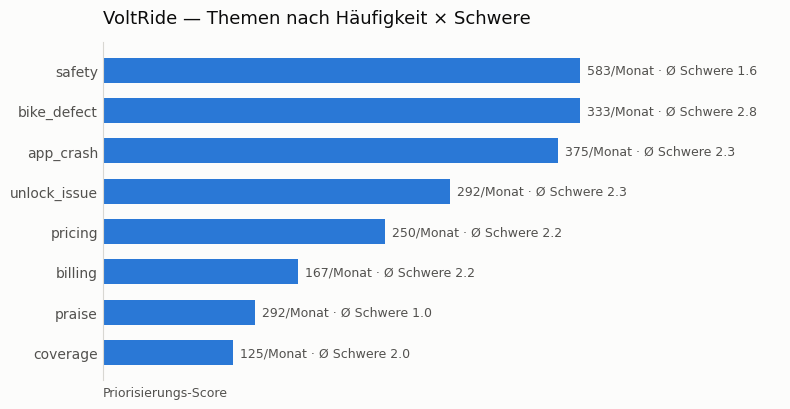

In [ ]:
import matplotlib.pyplot as plt

BLAU, TINTE, GRAU, FLAECHE = "#2a78d6", "#0b0b0b", "#52514e", "#fcfcfb"
d = roadmap.sort_values("score")

fig, ax = plt.subplots(figsize=(8, 4.2), facecolor=FLAECHE)
ax.set_facecolor(FLAECHE)
ax.barh(d.index, d.score, color=BLAU, height=0.62)
for y, (s, n, sw) in enumerate(zip(d.score, d.pro_monat, d.schwere)):
    ax.text(s + max(d.score)*0.015, y, f"{n}/Monat · Ø Schwere {sw:.1f}",
            va="center", fontsize=9, color=GRAU)
ax.set_title("VoltRide — Themen nach Häufigkeit × Schwere", fontsize=13,
             color=TINTE, pad=14, loc="left")
ax.set_xlabel("Priorisierungs-Score", fontsize=9, color=GRAU, loc="left")
ax.set_xlim(0, max(d.score) * 1.42)
for s in ("top","right","bottom"): ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#d8d7d2")
ax.tick_params(length=0, labelsize=10, colors=GRAU)
ax.set_xticks([])
plt.tight_layout()
plt.savefig("roadmap_voltride.png", dpi=200, facecolor=FLAECHE)
plt.show()

In [ ]:
PREISE = {                          # $ pro 1 Mio. Token
    "Groq gpt-oss-20b (frei)": (0.075, 0.30),
    "Claude Haiku 4.5":        (1.00,  5.00),
    "Claude Sonnet 5":         (2.00, 10.00),
}
T_EIN = int(BEST[BEST.ok].tokens_ein.mean())     # gemessen, nicht geschätzt
T_AUS = int(BEST[BEST.ok].tokens_aus.mean())

print(f"Gemessen: {T_EIN} Input-, {T_AUS} Output-Token pro Eintrag")
print(f"Bei {MONATSVOLUMEN} Rückmeldungen/Monat:\n")
for name,(pe,pa) in PREISE.items():
    k = (T_EIN*pe + T_AUS*pa) * MONATSVOLUMEN / 1_000_000
    print(f"  {name:26s} {k:7.2f} $/Monat   {k*12:8.2f} $/Jahr")

print("\n🔧 Vergleich: Was kostet die Werkstudentin, die heute 150 Einträge liest?")
print("   Diese Gegenüberstellung ist der Business Case, nicht die Genauigkeit.")

Gemessen: 289 Input-, 74 Output-Token pro Eintrag
Bei 2500 Rückmeldungen/Monat:

  Groq gpt-oss-20b (frei)       0.11 $/Monat       1.32 $/Jahr
  Claude Haiku 4.5              1.65 $/Monat      19.77 $/Jahr
  Claude Sonnet 5               3.29 $/Monat      39.54 $/Jahr

🔧 Vergleich: Was kostet die Werkstudentin, die heute 150 Einträge liest?
   Diese Gegenüberstellung ist der Business Case, nicht die Genauigkeit.


---
## Checkliste vor dem Schreiben

- [ ] Alle Läufe mit Erfolgsquote 100 %
- [ ] `fehler_v1.csv` von Hand codiert, strittige Labels markiert
- [ ] Mindestens drei Zeilen im `PROTOKOLL` mit benannten Eingriffen
- [ ] Mindestens eine **Regression** dokumentiert
- [ ] Eine Fehlerklasse benannt, die sich **nicht** per Prompt lösen lässt
- [ ] Sicherheits-Recall separat erklärt
- [ ] `roadmap_voltride.png` als Website-Bild
- [ ] Kostenvergleich Mensch gegen Modell
- [ ] `Laufzeit → Sitzung neu starten und alle ausführen` läuft sauber durch
- [ ] Hinweis auf die fiktive Datenbasis steht **oben** in der Case Study